# SDM-модель методом MaxEnt

Данный блокнот строит модель **MaxEnt** по готовым GeoTIFF-предикторам и CSV-файла с точками присутствия борщевика Сосновского.

## Этапы работы

1. Берёт данные из папки `data_predictors`.
2. Использует только `.tif`-растры-предикторы и `.csv` с точками присутствия.
3. Проверяет, что все растры лежат на одной сетке: одинаковый CRS, размер, а также мультиколлинеарность
4. Генерирует фоновые точки.
5. Извлекает значения предикторов в точках присутствия и фоновых точках.
6. Обучает модель MaxEnt.
7. Считает AUC на train/test.
8. Считает **пермутационную важность предикторов**.
9. Строит итоговый GeoTIFF-прогноз `maxent_prediction.tif`.

## 1. Установка библиотек

Для запуска в Google Colab нужна библиотека `elapid`


In [1]:
# Установка elapid для MaxEnt
!pip install elapid -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.5/436.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 52.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


## 2. Подключение Google Drive


In [2]:
# Подключение Google Drive в Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Настройки проекта

Измени `DATA_DIR`, если папка с данными лежит в другом месте. В этой папке должны быть:

- `.tif` — растры-предикторы;
- `.csv` — точки присутствия вида `lon/lat`, `longitude/latitude` или `x/y`.


In [3]:
# =========================
# НАСТРОЙКИ
# =========================

# Основной путь к папке с данными.
# Если путь не найден, код ниже дополнительно проверит альтернативные варианты.
DATA_DIR = "/content/drive/MyDrive/data_predictors"

# Если CSV с точками присутствия называется конкретно, можно указать имя файла.
# Если оставить None, будет взят первый CSV-файл в папке DATA_DIR.
PRESENCE_CSV_NAME = None

# CRS координат в CSV.
# None означает: считать, что точки уже в CRS растров.
POINTS_CRS = None

# Количество фоновых точек для MaxEnt.
BACKGROUND_COUNT = 10_000

# Параметры MaxEnt.
MAXENT_TRANSFORM = "cloglog"
BETA_MULTIPLIER = 1.0

# Разделение данных для оценки качества.
TEST_SIZE = 0.25
RANDOM_SEED = 42

# Пермутационная важность.
PERMUTATION_REPEATS = 10

# Размер блока при записи прогноза.
BLOCK_SIZE = 256

# Имена выходных файлов.
OUTPUT_RASTER_NAME = "maxent_prediction.tif"
MODEL_NAME = "maxent_model.ela"
PERMUTATION_IMPORTANCE_NAME = "permutation_importance.csv"

## 4. Импорт библиотек и вспомогательные функции

In [21]:
import os
import glob
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import elapid as ela
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import train_test_split
from rasterio.windows import Window

warnings.filterwarnings("ignore", category=UserWarning)


def resolve_data_dir(data_dir):
    """Возвращает существующую папку с данными."""
    candidates = [
        data_dir,
        "/content/drive/MyDrive/data_predictors",
        "/content/drive/MyDrive/data_predictors",
    ]

    for candidate in candidates:
        if candidate and os.path.isdir(candidate):
            return candidate

def find_coordinate_columns(df):
    """Автоматически ищет колонки X/Y в CSV с точками присутствия."""
    possible_x_cols = [
        "x", "X",
        "lon", "Lon", "LON",
        "lng", "Lng", "LNG",
        "long", "Long", "LONG",
        "longitude", "Longitude", "LONGITUDE",
        "decimalLongitude", "DecimalLongitude",
    ]

    possible_y_cols = [
        "y", "Y",
        "lat", "Lat", "LAT",
        "latitude", "Latitude", "LATITUDE",
        "decimalLatitude", "DecimalLatitude",
    ]

    x_col = next((col for col in possible_x_cols if col in df.columns), None)
    y_col = next((col for col in possible_y_cols if col in df.columns), None)

    if x_col is None or y_col is None:
        raise ValueError(
            "Не найдены колонки координат. "
            "Переименуй их в lon/lat, longitude/latitude или x/y."
        )

    return x_col, y_col


def validate_rasters(raster_paths):
    """Проверяет, что все растры имеют одинаковую сетку."""
    if len(raster_paths) == 0:
        raise FileNotFoundError("В папке не найдено входных .tif-растров.")

    with rasterio.open(raster_paths[0]) as src0:
        ref_shape = src0.shape
        ref_crs = src0.crs
        ref_transform = src0.transform

    if ref_crs is None:
        raise ValueError(
            "У первого GeoTIFF нет CRS. Нужно записать CRS в растры перед запуском модели."
        )

    for raster_path in raster_paths:
        with rasterio.open(raster_path) as src:
            if src.shape != ref_shape:
                raise ValueError(
                    f"Растр {os.path.basename(raster_path)} имеет размер {src.shape}, "
                    f"а должен быть {ref_shape}. Нужно выровнять растры."
                )

            if src.crs != ref_crs:
                raise ValueError(
                    f"CRS растра {os.path.basename(raster_path)} отличается от первого растра."
                )

            if src.transform != ref_transform:
                raise ValueError(
                    f"Transform растра {os.path.basename(raster_path)} отличается от первого растра. "
                    "Все предикторы должны быть на одной сетке."
                )

    return ref_shape, ref_crs, ref_transform

## 5. Поиск входных данных

Из папки берутся только `.tif`-файлы.

In [5]:
data_dir = resolve_data_dir(DATA_DIR)
print("Папка с данными:", data_dir)

# Исключаем выходные файлы предыдущих запусков.
excluded_tif_names = {
    OUTPUT_RASTER_NAME,
    "maxent_prediction_blocks.tif",
    "prediction.tif",
}

all_tifs = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
raster_paths_for_maxent = [
    path for path in all_tifs
    if os.path.basename(path) not in excluded_tif_names
]

if PRESENCE_CSV_NAME is None:
    csv_files = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if len(csv_files) == 0:
        raise FileNotFoundError("В папке data_predictors не найден CSV с точками присутствия.")
    presence_csv_path = csv_files[0]
else:
    presence_csv_path = os.path.join(data_dir, PRESENCE_CSV_NAME)
    if not os.path.exists(presence_csv_path):
        raise FileNotFoundError(f"CSV-файл не найден: {presence_csv_path}")

print("Найдено GeoTIFF-предикторов:", len(raster_paths_for_maxent))
for path in raster_paths_for_maxent:
    print(" -", os.path.basename(path))

print("CSV с точками присутствия:", os.path.basename(presence_csv_path))

Папка с данными: /content/drive/MyDrive/data_predictors
Найдено GeoTIFF-предикторов: 7
 - abandoned_lands.tif
 - dist_to_river.tif
 - dist_to_road.tif
 - dist_to_villages.tif
 - precipitation.tif
 - soil_types.tif
 - twi_index.tif
CSV с точками присутствия: points_plants.csv


## 6. Загрузка точек присутствия и проверка растров

Важно: точки присутствия и растры должны быть в одинаковых системах координатах (EPSG:4326).

In [6]:
# Проверяем растры.
raster_shape, raster_crs, raster_transform = validate_rasters(raster_paths_for_maxent)

print("CRS растров:", raster_crs)
print("Размер растров:", raster_shape)
print("Все растры имеют одинаковый CRS, размер и transform.")

# Файл CSV с точками присутствия.
presence_df = pd.read_csv(presence_csv_path)
print("Первые строки CSV:")
print(presence_df.head())

x_col, y_col = find_coordinate_columns(presence_df)
print("Колонка X:", x_col)
print("Колонка Y:", y_col)

# Оставляем только строки с корректными координатами.
presence_df = presence_df.copy()
presence_df[x_col] = pd.to_numeric(presence_df[x_col], errors="coerce")
presence_df[y_col] = pd.to_numeric(presence_df[y_col], errors="coerce")
presence_df = presence_df.dropna(subset=[x_col, y_col])

if len(presence_df) == 0:
    raise ValueError("После удаления пустых координат в CSV не осталось точек.")

# CRS точек.
points_crs = POINTS_CRS if POINTS_CRS is not None else raster_crs

presence_gdf = gpd.GeoDataFrame(
    presence_df,
    geometry=gpd.points_from_xy(presence_df[x_col], presence_df[y_col]),
    crs=points_crs,
)

if presence_gdf.crs != raster_crs:
    presence_gdf = presence_gdf.to_crs(raster_crs)

print("Точек присутствия:", len(presence_gdf))

CRS растров: EPSG:4326
Размер растров: (4801, 7958)
Все растры имеют одинаковый CRS, размер и transform.
Первые строки CSV:
                species        lon        lat
0  Heracleum sosnowskyi  36.348024  55.818800
1  Heracleum sosnowskyi  36.269125  55.778401
2  Heracleum sosnowskyi  36.034920  56.058520
3  Heracleum sosnowskyi  35.761796  56.060979
4  Heracleum sosnowskyi  36.180913  55.779850
Колонка X: lon
Колонка Y: lat
Точек присутствия: 441


Всего валидных пикселей: 20528014
Пикселей использовано для корреляции: 100000

Матрица корреляции:
                  abandoned_lands  dist_to_river  dist_to_road  \
abandoned_lands             1.000         -0.070        -0.128   
dist_to_river              -0.070          1.000         0.167   
dist_to_road               -0.128          0.167         1.000   
dist_to_villages           -0.096          0.101         0.081   
precipitation               0.040         -0.083        -0.127   
soil_types                 -0.041         -0.117         0.007   
twi_index                   0.171         -0.093        -0.013   

                  dist_to_villages  precipitation  soil_types  twi_index  
abandoned_lands             -0.096          0.040      -0.041      0.171  
dist_to_river                0.101         -0.083      -0.117     -0.093  
dist_to_road                 0.081         -0.127       0.007     -0.013  
dist_to_villages             1.000         -0.058       0.084     -0.00

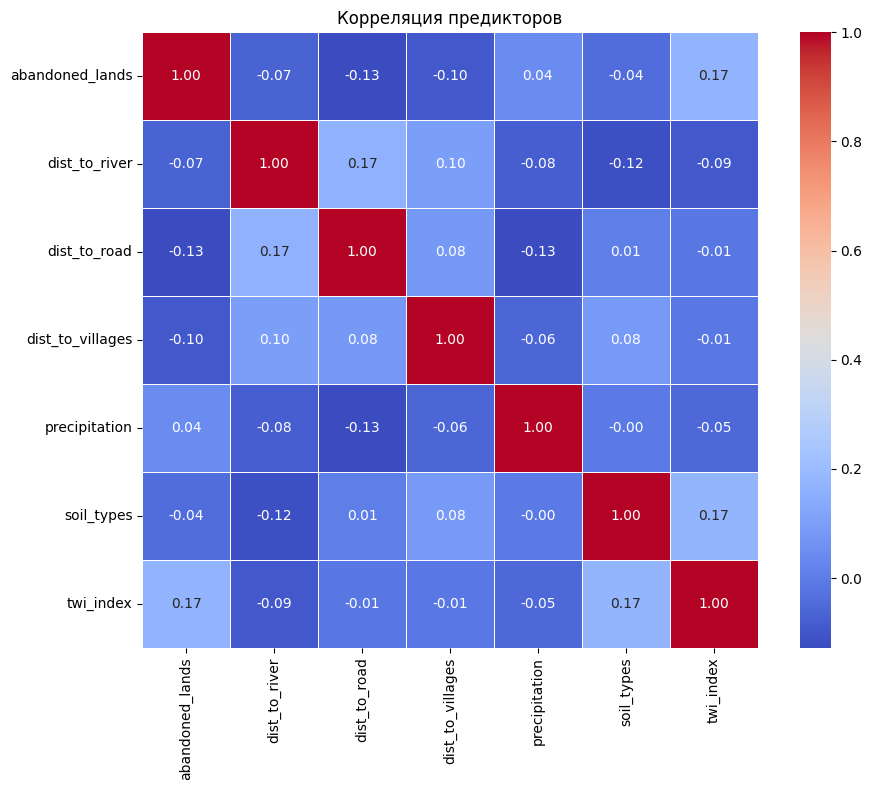

In [23]:
# ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ РАСТРОВ-ПРЕДИКТОРОВ

# Порог высокой корреляции
correlation_threshold = 0.7

# Сколько случайных пикселей использовать для расчёта корреляции
sample_size = 100000

predictor_names = [
    os.path.splitext(os.path.basename(path))[0]
    for path in raster_paths_for_maxent
]

sampled_values = []

for rp in raster_paths_for_maxent:
    with rasterio.open(rp) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

        if nodata is not None:
            arr[arr == nodata] = np.nan

        arr = arr.flatten()
        sampled_values.append(arr)

# Собираем значения всех растров в одну таблицу
raster_values = np.vstack(sampled_values).T

# Убираем пиксели, где хотя бы в одном предикторе есть NaN
valid_mask = np.all(np.isfinite(raster_values), axis=1)
raster_values = raster_values[valid_mask]

print("Всего валидных пикселей:", raster_values.shape[0])

if raster_values.shape[0] == 0:
    raise ValueError(
        "Нет валидных пикселей для расчёта корреляции. "
        "Проверь NoData и совпадение экстентов растров."
    )

# Если валидных пикселей очень много, берем случайную подвыборку
if raster_values.shape[0] > sample_size:
    np.random.seed(42)
    sample_indices = np.random.choice(
        raster_values.shape[0],
        size=sample_size,
        replace=False
    )
    raster_values = raster_values[sample_indices]

print("Пикселей использовано для корреляции:", raster_values.shape[0])

raster_df = pd.DataFrame(
    raster_values,
    columns=predictor_names
)

# Матрица корреляции
correlation_matrix = raster_df.corr(method="pearson")

print("\nМатрица корреляции:")
print(correlation_matrix.round(3))

# Сохраняем матрицу корреляции
correlation_csv_path = os.path.join(data_dir, "predictor_correlation_matrix.csv")
correlation_matrix.to_csv(correlation_csv_path)

print("\nМатрица корреляции сохранена:", correlation_csv_path)

# Ищем пары с высокой корреляцией
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        var_1 = correlation_matrix.columns[i]
        var_2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= correlation_threshold:
            high_corr_pairs.append({
                "predictor_1": var_1,
                "predictor_2": var_2,
                "correlation": corr_value,
                "abs_correlation": abs(corr_value)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_df) > 0:
    high_corr_df = high_corr_df.sort_values(
        "abs_correlation",
        ascending=False
    )

    print(f"\nПары с |correlation| >= {correlation_threshold}:")
    print(high_corr_df)

    high_corr_csv_path = os.path.join(data_dir, "highly_correlated_predictors.csv")
    high_corr_df.to_csv(high_corr_csv_path, index=False)

    print("\nСписок высоко коррелирующих пар сохранён:", high_corr_csv_path)
else:
    print(f"\nПар с |correlation| >= {correlation_threshold} не найдено.")

# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Корреляция предикторов")
plt.tight_layout()

correlation_png_path = os.path.join(data_dir, "predictor_correlation_heatmap.png")
plt.savefig(correlation_png_path, dpi=300, bbox_inches="tight")

plt.show()

## 7. Фоновые точки и извлечение значений предикторов

MaxEnt обучается на точках присутствия и фоновых точках, поэтому для данных точек извлекаются значения из каждого растрового предиктора.

In [7]:
# Генерируем фоновые точки по первому растровому предиктору.
background_gdf = ela.sample_raster(
    raster_paths_for_maxent[0],
    count=BACKGROUND_COUNT,
)

if background_gdf.crs is None:
    background_gdf = background_gdf.set_crs(raster_crs, allow_override=True)

if background_gdf.crs != raster_crs:
    background_gdf = background_gdf.to_crs(raster_crs)

print("Фоновых точек:", len(background_gdf))

# Объединяем presence и background, добавляем class:
# class = 1 для точек присутствия, class = 0 для фоновых точек.
merged_gdf = ela.stack_geodataframes(
    presence_gdf,
    background_gdf,
    add_class_label=True,
)

# Извлекаем значения растров в точках.
annotated = ela.annotate(
    merged_gdf,
    raster_paths_for_maxent,
    drop_na=True,
    quiet=True,
)

if len(annotated) == 0:
    raise ValueError(
        "После annotate получилось 0 строк. "
        "Точки не попадают на растры или в предикторах слишком много NoData."
    )

print("Строк после annotate:", len(annotated))
print("Первые строки таблицы для обучения:")
print(annotated.head())

Фоновых точек: 10000
Строк после annotate: 5799
Первые строки таблицы для обучения:
                    geometry  class  b1    b2    b3     b4  b5   b6  b7
0   POINT (36.34802 55.8188)      1   5   840  3672   2173  86   38 -10
1   POINT (36.26913 55.7784)      1   4  1830   134   1878  85  307  -8
2  POINT (36.03492 56.05852)      1   5  9918   152  12902  85   39 -10
3   POINT (35.7618 56.06098)      1   4  3380   818   2713  84   38  -6
4  POINT (36.18091 55.77985)      1   4  2190  1230   7788  84   39  -8


## 8. Обучение и оценка MaxEnt

Модель обучается на части данных, а качество оценивается по AUC-критерию на обучающей и тестовой выборках

In [9]:
# ОБУЧЕНИЕ MAXENT

X = annotated.drop(columns=["geometry", "class"])
y = annotated["class"].astype(int)

print("Предикторы модели:")
print(list(X.columns))

# Stratify используется, чтобы сохранить долю presence и background в тестовой и обучающей выборках
stratify = y if y.nunique() == 2 and y.value_counts().min() > 1 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=stratify,
)

model = ela.MaxentModel(
    transform=MAXENT_TRANSFORM,
    beta_multiplier=BETA_MULTIPLIER,
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_auc = metrics.roc_auc_score(y_train, train_pred)
test_auc = metrics.roc_auc_score(y_test, test_pred)

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")

model_path = os.path.join(data_dir, MODEL_NAME)
ela.save_object(model, model_path)
print("Модель сохранена:", model_path)

Предикторы модели:
['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7']
Train AUC: 0.856
Test AUC:  0.831
Модель сохранена: /content/drive/MyDrive/data_predictors/maxent_model.ela


## 9. Пермутационная важность предикторов

Пермутационная важность показывает, насколько падает AUC, если случайно перемешать значения одного предиктора. Чем больше падение AUC, тем важнее предиктор для модели.

Результат сохраняется в `permutation_importance.csv`.

Пермутационная важность сохранена: /content/drive/MyDrive/data_predictors/permutation_importance.csv
  predictor  baseline_auc  mean_permuted_auc  std_permuted_auc  auc_drop
0        b1      0.831384           0.636982          0.016931  0.194402
1        b3      0.831384           0.798769          0.006368  0.032615
2        b5      0.831384           0.814590          0.005962  0.016794
3        b7      0.831384           0.820439          0.005764  0.010945
4        b6      0.831384           0.822602          0.005225  0.008782
5        b2      0.831384           0.824956          0.003762  0.006428
6        b4      0.831384           0.826396          0.001585  0.004988


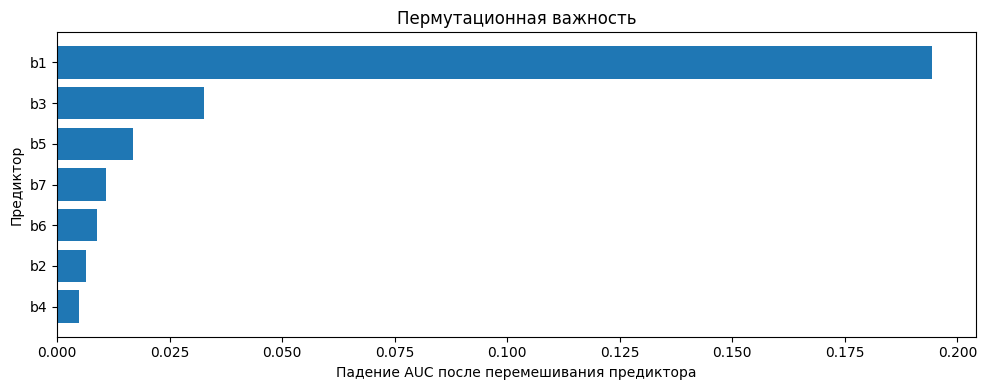

In [11]:
# ПЕРМУТАЦИОННАЯ ВАЖНОСТЬ

rng = np.random.default_rng(RANDOM_SEED)

# Важность считается на тестовой выборке.
importance_X = X_test.copy()
importance_y = y_test.copy()
baseline_auc = metrics.roc_auc_score(importance_y, model.predict(importance_X))

importance_rows = []

for feature in importance_X.columns:
    permuted_aucs = []

    for _ in range(PERMUTATION_REPEATS):
        X_permuted = importance_X.copy()
        X_permuted[feature] = rng.permutation(X_permuted[feature].to_numpy())

        permuted_pred = model.predict(X_permuted)
        permuted_auc = metrics.roc_auc_score(importance_y, permuted_pred)
        permuted_aucs.append(permuted_auc)

    mean_permuted_auc = float(np.mean(permuted_aucs))
    std_permuted_auc = float(np.std(permuted_aucs))
    auc_drop = float(baseline_auc - mean_permuted_auc)

    importance_rows.append({
        "predictor": feature,
        "baseline_auc": baseline_auc,
        "mean_permuted_auc": mean_permuted_auc,
        "std_permuted_auc": std_permuted_auc,
        "auc_drop": auc_drop,
    })

permutation_importance = (
    pd.DataFrame(importance_rows)
    .sort_values("auc_drop", ascending=False)
    .reset_index(drop=True)
)

importance_path = os.path.join(data_dir, PERMUTATION_IMPORTANCE_NAME)
permutation_importance.to_csv(importance_path, index=False)

print("Пермутационная важность сохранена:", importance_path)
print(permutation_importance)

# Визуализация пермутационной важности.
plt.figure(figsize=(10, max(4, 0.45 * len(permutation_importance))))
plt.barh(
    permutation_importance["predictor"][::-1],
    permutation_importance["auc_drop"][::-1],
)
plt.xlabel("Падение AUC после перемешивания предиктора")
plt.ylabel("Предиктор")
plt.title("Пермутационная важность")
plt.tight_layout()
plt.show()

## 10. Прогноз распространения вида по растрам

Прогноз считается блоками, чтобы не загружать все растры целиком в память


In [12]:
# ПРОГНОЗ ПО РАСТРАМ БЛОКАМ

output_raster = os.path.join(data_dir, OUTPUT_RASTER_NAME)

with rasterio.open(raster_paths_for_maxent[0]) as src0:
    profile = src0.profile.copy()
    height = src0.height
    width = src0.width

profile.update(
    driver="GTiff",
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="lzw",
)

with rasterio.open(output_raster, "w", **profile) as dst:
    total_blocks = int(np.ceil(height / BLOCK_SIZE) * np.ceil(width / BLOCK_SIZE))
    processed_blocks = 0

    for row_start in range(0, height, BLOCK_SIZE):
        for col_start in range(0, width, BLOCK_SIZE):
            win_height = min(BLOCK_SIZE, height - row_start)
            win_width = min(BLOCK_SIZE, width - col_start)

            window = Window(
                col_start,
                row_start,
                win_width,
                win_height,
            )

            block_arrays = []

            for raster_path in raster_paths_for_maxent:
                with rasterio.open(raster_path) as src:
                    arr = src.read(1, window=window).astype("float32")

                    nodata = src.nodata
                    if nodata is not None:
                        arr[arr == nodata] = np.nan

                    block_arrays.append(arr)

            block_stack = np.stack(block_arrays, axis=-1)
            valid_mask = np.all(np.isfinite(block_stack), axis=-1)

            prediction_block = np.full(
                (win_height, win_width),
                -9999.0,
                dtype="float32",
            )

            if valid_mask.sum() > 0:
                flat_values = block_stack[valid_mask]
                predict_df = pd.DataFrame(flat_values, columns=X.columns)
                prediction_block[valid_mask] = model.predict(predict_df).astype("float32")

            dst.write(prediction_block, 1, window=window)

            processed_blocks += 1
            if processed_blocks % 25 == 0 or processed_blocks == total_blocks:
                print(f"Обработано блоков: {processed_blocks}/{total_blocks}")

print("Карта пригодности сохранена:", output_raster)

Обработано блоков: 25/608
Обработано блоков: 50/608
Обработано блоков: 75/608
Обработано блоков: 100/608
Обработано блоков: 125/608
Обработано блоков: 150/608
Обработано блоков: 175/608
Обработано блоков: 200/608
Обработано блоков: 225/608
Обработано блоков: 250/608
Обработано блоков: 275/608
Обработано блоков: 300/608
Обработано блоков: 325/608
Обработано блоков: 350/608
Обработано блоков: 375/608
Обработано блоков: 400/608
Обработано блоков: 425/608
Обработано блоков: 450/608
Обработано блоков: 475/608
Обработано блоков: 500/608
Обработано блоков: 525/608
Обработано блоков: 550/608
Обработано блоков: 575/608
Обработано блоков: 600/608
Обработано блоков: 608/608
Карта пригодности сохранена: /content/drive/MyDrive/data_predictors/maxent_prediction.tif


## 11. Визуализация карты пригодности местообитаний для распространения борщевика Сосновского

Чем выше значение вероятности пригодности местообитаний, тем выше вероятность произрастания борщевика Сосновского на данных участках

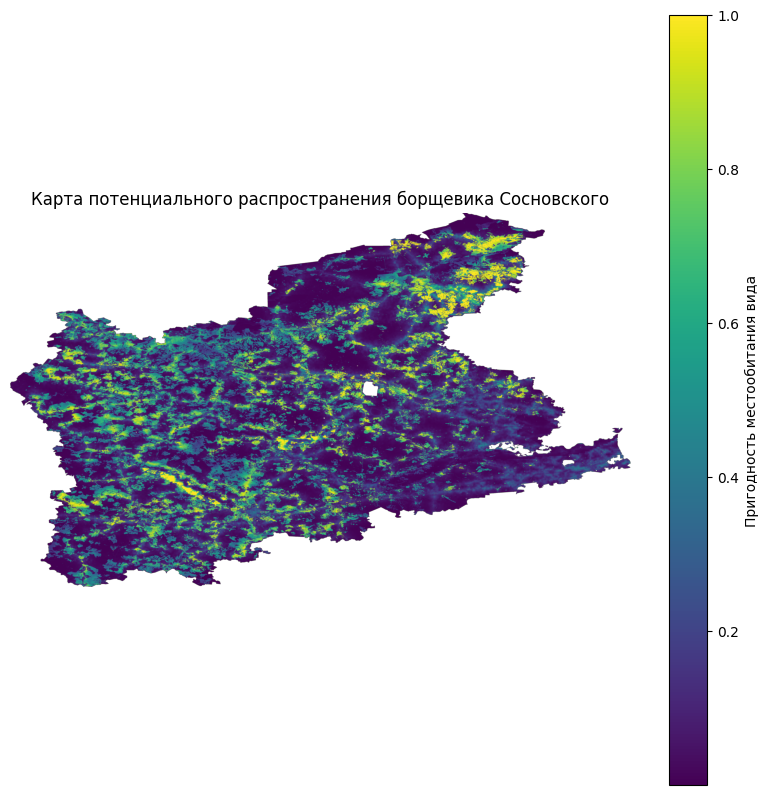

In [16]:
# ВИЗУАЛИЗАЦИЯ ПРОГНОЗНОЙ КАРТЫ

with rasterio.open(output_raster) as src:
    prediction = src.read(1).astype("float32")
    nodata = src.nodata
    if nodata is not None:
        prediction[prediction == nodata] = np.nan

plt.figure(figsize=(10, 10))
plt.imshow(prediction)
plt.colorbar(label="Пригодность местообитания вида")
plt.title("Карта потенциального распространения борщевика Сосновского")
plt.axis("off")
plt.show()

## 12. Итоговые файлы

После запуска в папке `data_predictors` появятся:

- `maxent_model.ela` — сохраненная модель MaxEnt;
- `maxent_prediction.tif` — итоговая карта пригодности;
- `permutation_importance.csv` — таблица пермутационной важности предикторов.
